In [6]:
# Cell 1 — imports + setup
import os, json
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import joblib, time
import sys
sys.path.append("..")

from src.transforms import (
    get_preprocessor,
    get_preprocessor_fixed,
    compute_categories_list,
    numeric_features,
    categorical_features,
    select_cols_indices,
    get_feature_names_from_preprocessor
)
from src.artifacts import ensure_artifact_dirs, save_joblib_with_manifest, save_json_with_manifest

# constants
SEED = 42
ART_ROOT = "../artifacts"
FS_DIR = os.path.join(ART_ROOT, "feature_selection")
os.makedirs(FS_DIR, exist_ok=True)
ensure_artifact_dirs()
print("Feature-selection dir:", FS_DIR)


Feature-selection dir: ../artifacts\feature_selection


In [7]:
# Cell 2 — Load ONLY canonical splits (SAFE VERSION)

train_path = os.path.join(ART_ROOT, "data", "train.csv")
hold_path  = os.path.join(ART_ROOT, "data", "holdout.csv")

assert Path(train_path).exists(), "train.csv missing — run 01_data_prep first"
assert Path(hold_path).exists(), "holdout.csv missing — run 01_data_prep first"

train_df = pd.read_csv(train_path)
hold_df  = pd.read_csv(hold_path)

X_train = train_df.drop(columns=["num"])
y_train = train_df["num"].values

X_hold  = hold_df.drop(columns=["num"])
y_hold  = hold_df["num"].values

print("Train shape:", X_train.shape, "Hold shape:", X_hold.shape)

Train shape: (736, 15) Hold shape: (184, 15)


In [8]:
# Cell 3 — Build & fit a reproducible preprocessor (fixed categories) on TRAIN only
train_df = pd.read_csv(os.path.join(ART_ROOT, "data", "train.csv"))
X_train = train_df.drop(columns=["num"])
y_train = train_df["num"].values

# 1) compute categories_list from training set (ensures stable one-hot ordering)
featmap_path = os.path.join(FS_DIR, "feature_index_map.json")

if Path(featmap_path).exists():
    featmap = json.load(open(featmap_path))
    categories_list = featmap["categories_list"]
    print("Loaded categories_list from feature_index_map.json")
else:
    categories_list = compute_categories_list(X_train, categorical_features)
    print("Computed categories_list from train (fallback)")

# 2) build a preprocessor that *fixes* categories for OneHotEncoder (unfitted)
preproc_fixed = get_preprocessor_fixed(categories_list=categories_list)

# 3) fit on training set only (no leakage)
preproc_fixed.fit(X_train)
X_train_trans = preproc_fixed.transform(X_train)   # dense array expected

# 4) derive names and assert consistency
full_feature_names = get_feature_names_from_preprocessor(preproc_fixed, X_train.columns.tolist())
assert len(full_feature_names) == X_train_trans.shape[1], \
    f"Feature-name length {len(full_feature_names)} != transformed columns {X_train_trans.shape[1]}"

print("Total transformed features:", len(full_feature_names))
print(full_feature_names[:40])

# Save feature-index map for downstream notebooks
featmap = {
    "full_feature_names": full_feature_names,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "categories_list": categories_list
}
save_json_with_manifest(featmap, os.path.join(FS_DIR, "feature_index_map.json"), name="feature_index_map")
print("Saved/updated feature_index_map.json")

# Optional: also persist transformed arrays for faster experiments
np.save(os.path.join(FS_DIR, "X_train_trans.npy"), X_train_trans)
print("Saved X_train_trans shape:", X_train_trans.shape)


Loaded categories_list from feature_index_map.json
Total transformed features: 25
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Female', 'sex_Male', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_False', 'fbs_True', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'exang_False', 'exang_True', 'slope_downsloping', 'slope_flat', 'slope_upsloping', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect']
Saved/updated feature_index_map.json
Saved X_train_trans shape: (736, 25)


In [9]:
# Cell 4 — RFE ranking on transformed matrix (fast XGB base)
xgb_rfe = XGBClassifier(eval_metric='logloss', random_state=SEED, n_estimators=100, max_depth=3)
rfe = RFE(estimator=xgb_rfe, n_features_to_select=1, step=1)
rfe.fit(X_train_trans, y_train)
ranks = rfe.ranking_

df_rank = pd.DataFrame({"feature": full_feature_names, "rank": ranks})
df_rank = df_rank.sort_values("rank").reset_index(drop=True)
df_rank.to_csv(os.path.join(FS_DIR, "feature_ranks.csv"), index=False)
save_json_with_manifest(df_rank.to_dict(orient="records"),
                        os.path.join(FS_DIR, "feature_ranks.json"), name="feature_ranks")
print("Saved feature_ranks (csv + json). Top features:", df_rank['feature'].tolist()[:10])


Saved feature_ranks (csv + json). Top features: ['cp_asymptomatic', 'cp_atypical angina', 'sex_Female', 'thal_normal', 'ca', 'chol', 'oldpeak', 'age', 'slope_flat', 'thal_reversable defect']


In [10]:
# Cell 5 — Top-K CV using reproducible preprocessor inside the pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, roc_auc_score, average_precision_score

KMAX = min(25, len(full_feature_names))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

# use the top-level select_cols_indices (picklable)
for k in range(1, KMAX+1):
    top_features = df_rank['feature'].tolist()[:k]
    top_indices = [full_feature_names.index(f) for f in top_features]

    # portable selector (top-level)
    selector = FunctionTransformer(func=select_cols_indices, kw_args={"indices": top_indices}, validate=False)

    # pipeline: unfitted preprocessor (with fixed categories) -> selector -> xgb
    pipe = Pipeline([
        ("preproc", get_preprocessor_fixed(categories_list)),   # unfitted but with fixed categories
        ("selector", selector),
        ("xgb", XGBClassifier(eval_metric='logloss', random_state=SEED))
    ])

    # use cross_validate once to get both metrics
    scoring = {'roc_auc': 'roc_auc', 'avg_prec': 'average_precision'}
    t0 = time.time()
    cv_res = cross_validate(pipe, X_train, y_train, cv=skf, scoring=scoring, n_jobs=1, return_train_score=False)
    elapsed = time.time() - t0

    mean_auc = float(np.mean(cv_res['test_roc_auc']))
    std_auc  = float(np.std(cv_res['test_roc_auc']))
    mean_ap  = float(np.mean(cv_res['test_avg_prec']))
    std_ap   = float(np.std(cv_res['test_avg_prec']))

    # fit on full training for reference and save fitted pipeline (preprocessor will be fitted inside)
    pipe.fit(X_train, y_train)
    out_path = os.path.join(FS_DIR, f"pipeline_top{k}.joblib")
    save_joblib_with_manifest(pipe, out_path, name=f"pipeline_top{k}", notes=f"top-{k} features; cv_time_s={elapsed:.1f}")

    results.append({
        "k": k,
        "n_features": k,
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "mean_avg_precision": mean_ap,
        "std_avg_precision": std_ap,
        "model_artifact": out_path,
        "model_size_bytes": Path(out_path).stat().st_size
    })

    print(f"k={k} -> mean_auc={mean_auc:.4f} mean_ap={mean_ap:.4f} saved:{out_path}")

# Save results
df_results = pd.DataFrame(results)
df_results.to_csv(os.path.join(FS_DIR, "topk_results.csv"), index=False)
save_json_with_manifest(df_results.to_dict(orient="records"), os.path.join(FS_DIR, "topk_results.json"), name="topk_results")
print("Saved topk_results.csv and .json")


k=1 -> mean_auc=0.7465 mean_ap=0.7257 saved:../artifacts\feature_selection\pipeline_top1.joblib
k=2 -> mean_auc=0.7720 mean_ap=0.7450 saved:../artifacts\feature_selection\pipeline_top2.joblib
k=3 -> mean_auc=0.8063 mean_ap=0.7824 saved:../artifacts\feature_selection\pipeline_top3.joblib
k=4 -> mean_auc=0.8267 mean_ap=0.8169 saved:../artifacts\feature_selection\pipeline_top4.joblib
k=5 -> mean_auc=0.8347 mean_ap=0.8307 saved:../artifacts\feature_selection\pipeline_top5.joblib
k=6 -> mean_auc=0.8072 mean_ap=0.8173 saved:../artifacts\feature_selection\pipeline_top6.joblib
k=7 -> mean_auc=0.8239 mean_ap=0.8417 saved:../artifacts\feature_selection\pipeline_top7.joblib
k=8 -> mean_auc=0.8273 mean_ap=0.8335 saved:../artifacts\feature_selection\pipeline_top8.joblib
k=9 -> mean_auc=0.8373 mean_ap=0.8447 saved:../artifacts\feature_selection\pipeline_top9.joblib
k=10 -> mean_auc=0.8401 mean_ap=0.8493 saved:../artifacts\feature_selection\pipeline_top10.joblib
k=11 -> mean_auc=0.8423 mean_ap=0.8482

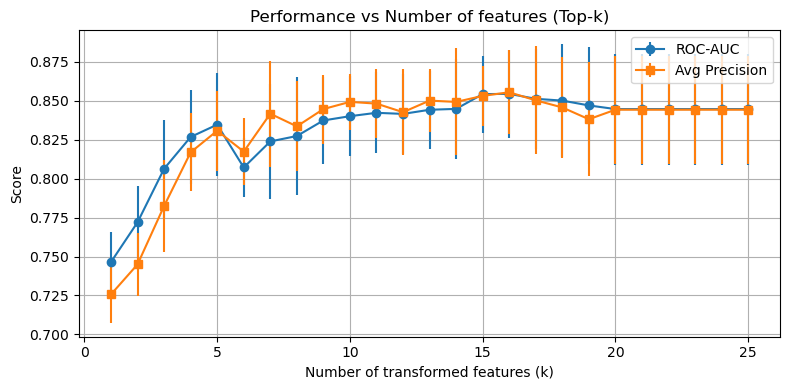

In [11]:
# Cell 6 — plot accuracy vs k (matplotlib inline)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.errorbar(df_results['k'], df_results['mean_auc'], yerr=df_results['std_auc'], label="ROC-AUC", marker='o')
plt.errorbar(df_results['k'], df_results['mean_avg_precision'], yerr=df_results['std_avg_precision'], label="Avg Precision", marker='s')
plt.xlabel("Number of transformed features (k)")
plt.ylabel("Score")
plt.title("Performance vs Number of features (Top-k)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FS_DIR, "topk_performance.png"), dpi=200)
plt.show()


In [12]:
# Evaluate saved pipelines on holdout
import os, numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from joblib import load
ART_ROOT = "../artifacts"
FS_DIR = os.path.join(ART_ROOT, "feature_selection")
hold_path = os.path.join(ART_ROOT, "data", "holdout.csv")
hold_df = pd.read_csv(hold_path)
X_hold = hold_df.drop(columns=["num"])
y_hold = hold_df["num"].values

results_hold = []
for k in range(1, len(full_feature_names)+1):
    ppath = os.path.join(FS_DIR, f"pipeline_top{k}.joblib")
    if not os.path.exists(ppath):
        continue
    pipe = load(ppath)
    # predict_proba
    try:
        probs = pipe.predict_proba(X_hold)[:,1]
    except Exception:
        # in case pipeline expects preprocessor.transform input
        preproc = pipe.named_steps.get("preproc", None)
        if preproc is not None:
            Xh_trans = preproc.transform(X_hold)
            # if selector exists, pipeline.predict_proba will handle it, but fallback:
            probs = pipe.predict_proba(X_hold)[:,1]
        else:
            raise
    auc = roc_auc_score(y_hold, probs)
    ap = average_precision_score(y_hold, probs)
    brier = brier_score_loss(y_hold, probs)
    results_hold.append({"k":k,"auc":auc,"ap":ap,"brier":brier,"path":ppath})
    print(f"k={k}  hold ROC-AUC={auc:.4f} AP={ap:.4f} Brier={brier:.4f}")

df_hold = pd.DataFrame(results_hold).sort_values("auc", ascending=False)
display(df_hold.head(10))


k=1  hold ROC-AUC=0.8069 AP=0.7801 Brier=0.1578
k=2  hold ROC-AUC=0.8280 AP=0.7952 Brier=0.1522
k=3  hold ROC-AUC=0.8608 AP=0.8341 Brier=0.1417
k=4  hold ROC-AUC=0.8795 AP=0.8645 Brier=0.1370
k=5  hold ROC-AUC=0.8577 AP=0.8518 Brier=0.1469
k=6  hold ROC-AUC=0.8404 AP=0.8535 Brier=0.1542
k=7  hold ROC-AUC=0.8760 AP=0.8736 Brier=0.1327
k=8  hold ROC-AUC=0.8832 AP=0.8912 Brier=0.1466
k=9  hold ROC-AUC=0.8783 AP=0.8659 Brier=0.1469
k=10  hold ROC-AUC=0.8827 AP=0.8819 Brier=0.1432
k=11  hold ROC-AUC=0.8865 AP=0.8723 Brier=0.1350
k=12  hold ROC-AUC=0.8890 AP=0.8768 Brier=0.1330
k=13  hold ROC-AUC=0.8873 AP=0.8767 Brier=0.1322
k=14  hold ROC-AUC=0.8901 AP=0.8925 Brier=0.1405
k=15  hold ROC-AUC=0.8960 AP=0.8860 Brier=0.1295
k=16  hold ROC-AUC=0.8960 AP=0.8818 Brier=0.1254
k=17  hold ROC-AUC=0.8944 AP=0.8976 Brier=0.1316
k=18  hold ROC-AUC=0.8826 AP=0.8821 Brier=0.1314
k=19  hold ROC-AUC=0.8739 AP=0.8485 Brier=0.1389
k=20  hold ROC-AUC=0.8843 AP=0.8807 Brier=0.1273
k=21  hold ROC-AUC=0.8843 AP=

,k,auc,ap,brier,path
15,16,0.896043,0.881786,0.125400,../artifacts\feature_selection\pipeline_top16....
14,15,0.896043,0.886005,0.129516,../artifacts\feature_selection\pipeline_top15....
16,17,0.894429,0.897596,0.131556,../artifacts\feature_selection\pipeline_top17....
13,14,0.890065,0.892534,0.140493,../artifacts\feature_selection\pipeline_top14....
11,12,0.889048,0.876786,0.132970,../artifacts\feature_selection\pipeline_top12....
12,13,0.887255,0.876674,0.132236,../artifacts\feature_selection\pipeline_top13....
10,11,0.886538,0.872346,0.135006,../artifacts\feature_selection\pipeline_top11....
20,21,0.884266,0.880715,0.127298,../artifacts\feature_selection\pipeline_top21....
23,24,0.884266,0.880715,0.127298,../artifacts\feature_selection\pipeline_top24....
24,25,0.884266,0.880715,0.127298,../artifacts\feature_selection\pipeline_top25....


In [13]:
# Quick function to build pipelines for given model and top_indices (uses get_preprocessor_fixed)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from src.transforms import get_preprocessor_fixed, select_cols_indices, compute_categories_list, categorical_features
import json, pathlib
path = "../artifacts/feature_selection/feature_index_map.json"
with open(path, "r") as f:
    featmap = json.load(f)
full_feature_names = featmap["full_feature_names"]
categories_list = featmap.get("categories_list", None)


# load train categories_list (from feature_index_map or compute from train)


def build_pipeline_for_topk(model, top_k, categories_list=categories_list):
    top_features = pd.read_csv("../artifacts/feature_selection/feature_ranks.csv")['feature'].tolist()[:top_k]
    top_indices = [full_feature_names.index(f) for f in top_features]
    preproc = get_preprocessor_fixed(categories_list)
    selector = FunctionTransformer(func=select_cols_indices, kw_args={"indices": top_indices}, validate=False)
    pipe = Pipeline([("preproc", preproc), ("selector", selector), ("model", model)])
    return pipe

# compare for k=7 and k=15
from sklearn.metrics import roc_auc_score, average_precision_score


for k in (7, 15, 16):
    print("---- k =", k)
    for name, model in [("XGB", XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)),
                        ("LR", LogisticRegression(max_iter=2000, solver='liblinear', random_state=42)),
                        ("MLP", MLPClassifier(max_iter=500, random_state=42))]:
        pipe = build_pipeline_for_topk(model, k)
        pipe.fit(X_train, y_train)
        probs = pipe.predict_proba(X_hold)[:,1]
        print(name, "hold AUC:", roc_auc_score(y_hold, probs), "AP:", average_precision_score(y_hold, probs))
    print()


---- k = 7
XGB hold AUC: 0.875956480153037 AP: 0.8735633374549544


C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:25:30] WARNING: D:\bld\xgboost-split_1764148481205\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


LR hold AUC: 0.9132592061214729 AP: 0.9218860159268323


C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:25:34] WARNING: D:\bld\xgboost-split_1764148481205\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP hold AUC: 0.9090746054519369 AP: 0.8974031712707649

---- k = 15
XGB hold AUC: 0.8960425633668101 AP: 0.8860054136289157
LR hold AUC: 0.9026781444285031 AP: 0.9005300909214856


C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:25:38] WARNING: D:\bld\xgboost-split_1764148481205\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP hold AUC: 0.8889287422285987 AP: 0.8579495917919668

---- k = 16
XGB hold AUC: 0.8960425633668101 AP: 0.8817863639479432
LR hold AUC: 0.9025585844093734 AP: 0.9002312539292818
MLP hold AUC: 0.9108082257293161 AP: 0.8963090103595901



C:\Users\Nikhil\anaconda3\envs\heartenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


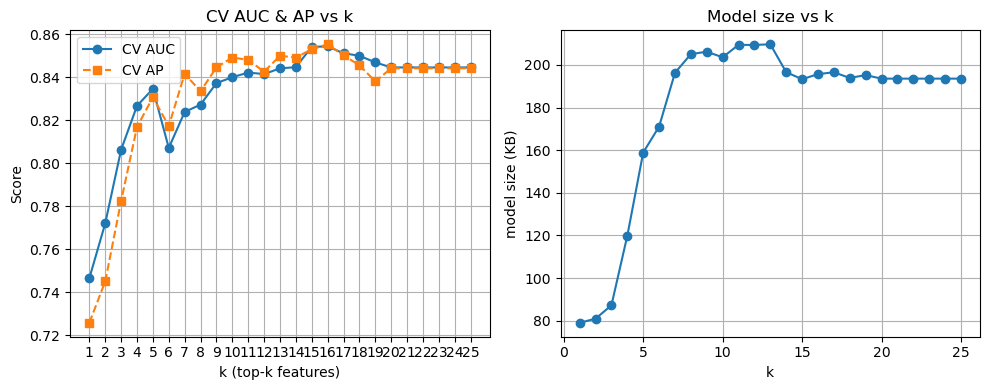

In [14]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os

df = pd.read_csv("../artifacts/feature_selection/topk_results.csv")
# ensure numeric model_size_bytes
df['model_size_bytes'] = pd.to_numeric(df['model_size_bytes'], errors='coerce')

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(df['k'], df['mean_auc'], marker='o', linestyle='-', label='CV AUC')
plt.plot(df['k'], df['mean_avg_precision'], marker='s', linestyle='--', label='CV AP')
plt.xticks(df['k'])
plt.xlabel("k (top-k features)")
plt.ylabel("Score")
plt.title("CV AUC & AP vs k")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(df['k'], df['model_size_bytes']/1024, marker='o')
plt.xlabel("k")
plt.ylabel("model size (KB)")
plt.title("Model size vs k")
plt.grid(True)
plt.tight_layout()
plt.savefig("../artifacts/feature_selection/topk_plots_combined.png", dpi=200)
plt.show()
